# Notebook 7 — Does the population distinguish condition A from B?

**Summer course: data-analysis pitfalls**

We recorded 600 neurons (across a handful of sessions) while the animal
experienced two conditions, A and B. For each neuron we compare its mean firing
on A trials vs. B trials. A colleague tested whether, across the population,
firing differs between conditions:

> ### The claim
> *"The population robustly distinguishes the two conditions: firing is higher on
> A trials than B trials (paired test across n = 600 neurons, p < 1e-12)."*

Run it and you'll get an astronomically small p-value.

**The claim is not supported by this analysis.** Your job is to work out *why*.
`hints.md` has guiding questions and `notebook7_solution.ipynb` has the answer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


In [2]:
d = np.load('data/data.npz')
activity = d['activity']        # (sessions, neurons, trials) firing rate
condition = d['condition']      # (sessions, trials)  +1 = A, -1 = B
arousal = d['arousal']          # (sessions, trials)  arousal per trial
n_sessions, n_neurons, n_trials = activity.shape
print(f'{n_sessions} sessions x {n_neurons} neurons = {n_sessions*n_neurons} neurons total')


6 sessions x 100 neurons = 600 neurons total


## Test A vs. B across all neurons

For each neuron, take its mean firing on A trials minus its mean on B trials,
then test whether that difference is non-zero across the population.


mean A-B = +0.42 spikes/s across 600 neurons
one-sample t-test: t = 7.4, p = 4.3e-13


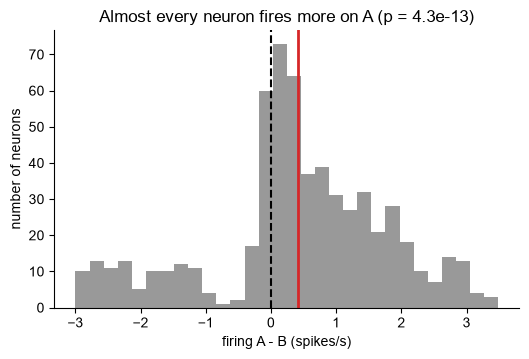

In [3]:
# per-neuron A-minus-B, pooling all neurons from all sessions
A = activity[:, :, condition[0] == 1].mean(2)     # (sessions, neurons) mean on A trials
B = activity[:, :, condition[0] == -1].mean(2)     # (sessions, neurons) mean on B trials
AmB = (A - B).ravel()                              # 600 neuron differences

t, p = stats.ttest_1samp(AmB, 0)
print(f'mean A-B = {AmB.mean():+.2f} spikes/s across {AmB.size} neurons')
print(f'one-sample t-test: t = {t:.1f}, p = {p:.1e}')

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(AmB, bins=30, color='0.6')
ax.axvline(0, color='k', ls='--'); ax.axvline(AmB.mean(), color='tab:red', lw=2)
ax.set_xlabel('firing A - B (spikes/s)'); ax.set_ylabel('number of neurons')
ax.set_title(f'Almost every neuron fires more on A (p = {p:.1e})')
plt.show()


Nearly every one of 600 neurons fires more on A than B, with a vanishingly small
p-value. Strong population coding of condition.
